# Censo de Población y Vivienda 2020 — Aguascalientes
## Brecha Digital y Logro Educativo a Nivel Localidad

**Objetivo**: Predecir el grado promedio de escolaridad (GRAPROES) a partir de indicadores
socioeconómicos derivados, e identificar clusters de marginación ocultos.

**Hipótesis**: El acceso digital (internet, computadora) es un predictor más fuerte del logro
educativo que los indicadores tradicionales de pobreza (calidad de vivienda, acceso a salud).

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gdown

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Carga y Limpieza de Datos

In [ ]:
# Aqui ponlo matias


In [ ]:
# --- Carga ---
folder_id = "1YH1UxyCxvj6BdptmOR3K_6XbZv8ipLMS"

gdown.download_folder(id=folder_id, output="data", quiet=False)

base_path = "data"

ruta_base = os.path.join(base_path, "datos.csv")

df_raw = pd.read_csv(ruta_base, low_memory=False, encoding="latin1")
print(f'Datos crudos: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')

# --- Limpieza de valores censales ---
VALORES_NA = ['*', 'N/D', 'ND', 'NA', 'nan', '.', '', ' ']

def limpiar_columna(serie):
    """Convierte asteriscos y marcadores censales a NaN numérico."""
    return (
        serie.astype(str).str.strip()
        .replace(VALORES_NA, np.nan)
        .str.replace(',', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

# Filtrar filas de totales y agregados
df = df_raw[
    (df_raw['MUN'] != 0) &
    (~df_raw['LOC'].isin([0, 9998, 9999]))
].copy()
print(f'Sin totales ni agregados: {len(df)} localidades')

# Limpiar columnas numéricas
cols_texto = ['NOM_ENT', 'NOM_MUN', 'NOM_LOC', 'LONGITUD', 'LATITUD']
for col in df.columns:
    if col not in cols_texto:
        df[col] = limpiar_columna(df[col])

# Filtrar localidades sin GRAPROES
df = df.dropna(subset=['GRAPROES'])
print(f'Con GRAPROES válido: {len(df)} localidades')

# --- Parsear coordenadas DMS a decimal ---
def dms_a_decimal(s):
    try:
        s = str(s).strip()
        if not s or s in ('nan', 'NaN'):
            return np.nan
        direccion = s[-1]
        partes = re.split(r'[°\'\"]', s[:-1].strip())
        partes = [p.strip() for p in partes if p.strip()]
        decimal = float(partes[0]) + float(partes[1]) / 60 + float(partes[2]) / 3600
        if direccion in ('W', 'S'):
            decimal = -decimal
        return decimal
    except Exception:
        return np.nan

df['lon'] = df['LONGITUD'].apply(dms_a_decimal)
df['lat'] = df['LATITUD'].apply(dms_a_decimal)
print(f'Coordenadas válidas: {df["lon"].notna().sum()} de {len(df)}')

Retrieving folder contents


Processing file 1LFbqEU1wu6qSASXFA-hY9B1NzUgMq5Jn code_ags.ipynb
Processing file 1X0tQKnMmna5Ppn1PMZksqeQfdkj6lxrD Copia de code_ags.ipynb
Processing file 1k-_ZsFiN67eJp4i28qLrIiCIzxNNKVw1 datos.csv
Processing file 16VJK5xD1aQZphDDRLCBiok9-EIYJCwMv diccionario.csv
Processing file 1zWSO89tEArhOcVRd9TIWHwAukLtpggJH inegi.ipynb


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1LFbqEU1wu6qSASXFA-hY9B1NzUgMq5Jn
To: /content/data/code_ags.ipynb
100%|██████████| 67.4k/67.4k [00:00<00:00, 7.90MB/s]
Downloading...
From: https://drive.google.com/uc?id=1X0tQKnMmna5Ppn1PMZksqeQfdkj6lxrD
To: /content/data/Copia de code_ags.ipynb
100%|██████████| 12.4k/12.4k [00:00<00:00, 25.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k-_ZsFiN67eJp4i28qLrIiCIzxNNKVw1
To: /content/data/datos.csv
100%|██████████| 1.53M/1.53M [00:00<00:00, 33.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=16VJK5xD1aQZphDDRLCBiok9-EIYJCwMv
To: /content/data/diccionario.csv
100%|██████████| 71.6k/71.6k [00:00<00:00, 61.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zWSO89tEArhOcVRd9TIWHwAukLtpggJH
To: /content/data/inegi.ipynb
100%|██████████| 1.25M/1.25M [00:00<00:00, 52.8MB/s]
Download completed


Datos crudos: 2058 filas x 286 columnas
Sin totales ni agregados: 2022 localidades
Con GRAPROES válido: 950 localidades
Coordenadas válidas: 0 de 950


In [ ]:
# Resumen por municipio
resumen = df.groupby('NOM_MUN')['POBTOT'].agg(['count', 'sum', 'median']).sort_values('sum', ascending=False)
resumen.columns = ['Localidades', 'Población Total', 'Población Mediana']
print('Localidades por municipio:')
resumen

Localidades por municipio:


,Localidades,Población Total,Población Mediana
NOM_MUN,,,
Aguascalientes,281,946443,38.0
JesÃºs MarÃ­a,131,129470,85.0
San Francisco de los Romo,36,61713,477.0
Calvillo,104,58014,85.5
RincÃ³n de Romos,80,56482,31.5
Asientos,88,51176,223.5
PabellÃ³n de Arteaga,73,47072,33.0
TepezalÃ¡,34,22205,273.0
El Llano,80,20000,31.0


## 2. Ingeniería de Variables

Los datos crudos del censo son **conteos absolutos** (ej. 50,000 personas con educación postbásica).
Estos correlacionan trivialmente con el tamaño de la localidad. Para un análisis significativo,
convertimos todo a **tasas y porcentajes** que capturan la estructura socioeconómica real.

In [ ]:
def tasa(numerador, denominador):
    """Calcula tasa segura: NaN donde denominador es 0 o NaN."""
    num = df[numerador].values.astype(float)
    den = df[denominador].values.astype(float)
    return np.where((den > 0) & (~np.isnan(den)) & (~np.isnan(num)), num / den, np.nan)

# --- Educación (base: población 15+ o 18+) ---
df['tasa_analfabetismo'] = tasa('P15YM_AN', 'P_15YMAS')
df['tasa_sin_escolaridad'] = tasa('P15YM_SE', 'P_15YMAS')
df['tasa_primaria_incompleta'] = tasa('P15PRI_IN', 'P_15YMAS')
df['tasa_postbasica'] = tasa('P18YM_PB', 'P_18YMAS')

# --- Acceso digital (base: viviendas particulares habitadas con características) ---
df['pct_internet'] = tasa('VPH_INTER', 'VIVPARH_CV')
df['pct_computadora'] = tasa('VPH_PC', 'VIVPARH_CV')
df['pct_celular'] = tasa('VPH_CEL', 'VIVPARH_CV')
df['pct_sin_tic'] = tasa('VPH_SINTIC', 'VIVPARH_CV')

# --- Salud ---
df['pct_sin_salud'] = tasa('PSINDER', 'POBTOT')

# --- Empleo (base: población 12+, PEA) ---
df['tasa_pea'] = tasa('PEA', 'P_12YMAS')
df['tasa_desempleo'] = tasa('PDESOCUP', 'PEA')

# --- Vivienda ---
df['pct_piso_tierra'] = tasa('VPH_PISOTI', 'VIVPARH_CV')
df['pct_sin_drenaje'] = tasa('VPH_NODREN', 'VIVPARH_CV')
df['pct_sin_servicios'] = tasa('VPH_NDEAED', 'VIVPARH_CV')

# PROM_HNV (promedio hijos nacidos vivos) y PRO_OCUP_C (ocupantes por cuarto) ya son tasas del INEGI

vars_derivadas = [
    'tasa_analfabetismo', 'tasa_sin_escolaridad', 'tasa_primaria_incompleta', 'tasa_postbasica',
    'pct_internet', 'pct_computadora', 'pct_celular', 'pct_sin_tic',
    'pct_sin_salud', 'tasa_pea', 'tasa_desempleo',
    'pct_piso_tierra', 'pct_sin_drenaje', 'pct_sin_servicios'
]
print('Variables derivadas creadas:')
df[vars_derivadas].describe().round(3)

Variables derivadas creadas:


,tasa_analfabetismo,tasa_sin_escolaridad,tasa_primaria_incompleta,tasa_postbasica,pct_internet,pct_computadora,pct_celular,pct_sin_tic,pct_sin_salud,tasa_pea,tasa_desempleo,pct_piso_tierra,pct_sin_drenaje,pct_sin_servicios
count,950.000,950.000,950.000,950.000,949.000,949.000,949.000,949.000,950.000,950.000,950.000,949.000,949.000,949.000
mean,0.049,0.055,0.134,0.261,0.318,0.209,0.897,0.014,0.225,0.614,0.013,0.025,0.072,0.010
std,0.066,0.073,0.110,0.192,0.254,0.209,0.121,0.052,0.175,0.135,0.035,0.080,0.163,0.075
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.167,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.068,0.137,0.125,0.033,0.837,0.000,0.118,0.533,0.000,0.000,0.000,0.000
50%,0.034,0.036,0.121,0.226,0.298,0.176,0.923,0.000,0.188,0.605,0.000,0.000,0.000,0.000
75%,0.067,0.077,0.174,0.333,0.450,0.284,1.000,0.006,0.290,0.684,0.013,0.014,0.055,0.000
max,0.667,1.000,1.000,1.000,1.000,1.000,1.000,0.667,1.000,1.000,0.583,1.000,1.000,1.000


In [ ]:
# Filtrar localidades pequeñas donde las tasas son poco confiables
MIN_POP = 50
df_analisis = df[df['POBTOT'] >= MIN_POP].copy()
pob_cubierta = df_analisis['POBTOT'].sum() / df['POBTOT'].sum() * 100
print(f'Localidades con población >= {MIN_POP}: {len(df_analisis)} de {len(df)}')
print(f'Población cubierta: {pob_cubierta:.1f}%')

Localidades con población >= 50: 495 de 950
Población cubierta: 99.3%


## 3. Análisis Exploratorio de Datos

### 3.1 Variable Objetivo: GRAPROES (Grado Promedio de Escolaridad)

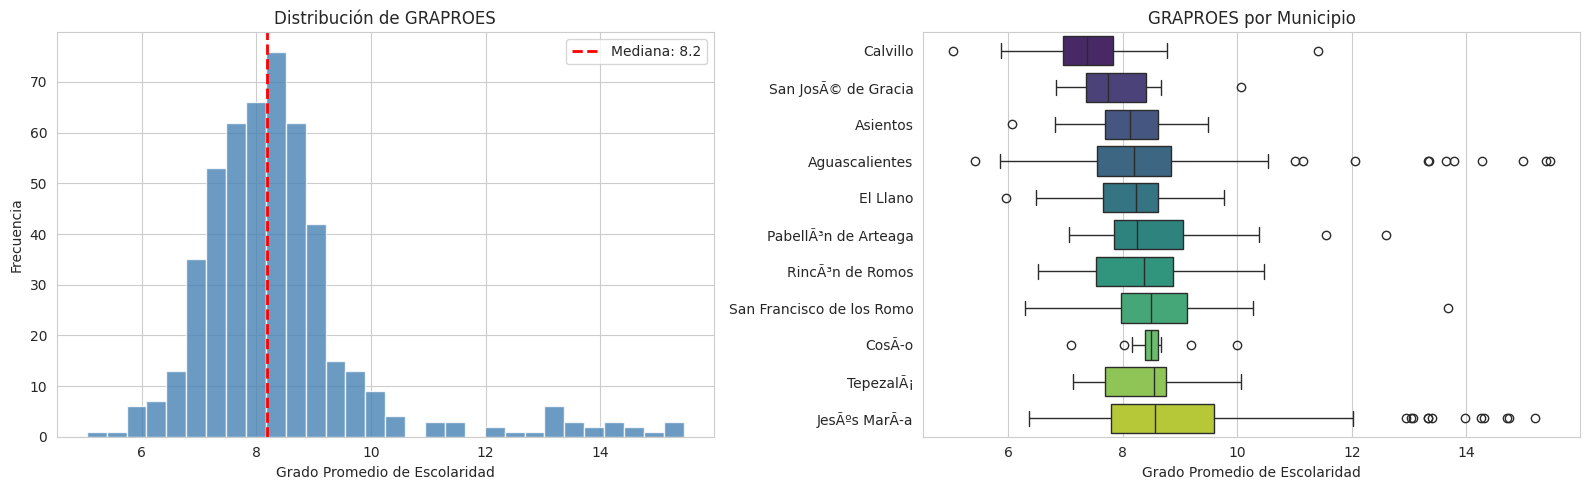

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
axes[0].hist(df_analisis['GRAPROES'].dropna(), bins=30, edgecolor='white', color='steelblue', alpha=0.8)
mediana = df_analisis['GRAPROES'].median()
axes[0].axvline(mediana, color='red', ls='--', lw=2, label=f'Mediana: {mediana:.1f}')
axes[0].set_xlabel('Grado Promedio de Escolaridad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de GRAPROES')
axes[0].legend()

# Boxplot por municipio
orden = df_analisis.groupby('NOM_MUN')['GRAPROES'].median().sort_values().index
sns.boxplot(data=df_analisis, y='NOM_MUN', x='GRAPROES', order=orden, ax=axes[1], palette='viridis')
axes[1].set_xlabel('Grado Promedio de Escolaridad')
axes[1].set_ylabel('')
axes[1].set_title('GRAPROES por Municipio')

plt.tight_layout()
plt.show()

### 3.2 Correlaciones

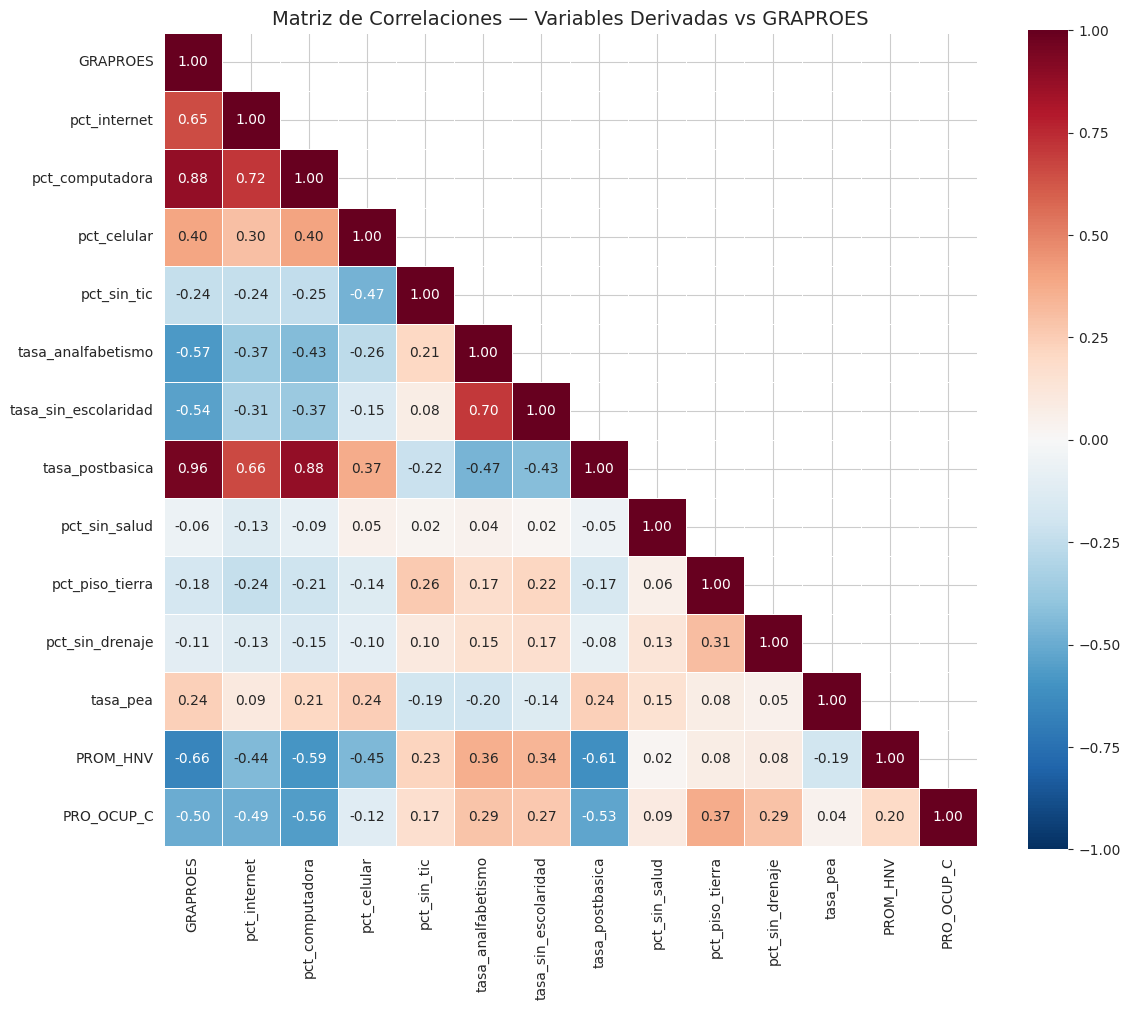


Correlaciones con GRAPROES:
tasa_postbasica         0.960
pct_computadora         0.876
PROM_HNV               -0.661
pct_internet            0.655
tasa_analfabetismo     -0.571
tasa_sin_escolaridad   -0.541
PRO_OCUP_C             -0.497
pct_celular             0.395
tasa_pea                0.240
pct_sin_tic            -0.238
pct_piso_tierra        -0.178
pct_sin_drenaje        -0.107
pct_sin_salud          -0.058


In [ ]:
cols_corr = [
    'GRAPROES', 'pct_internet', 'pct_computadora', 'pct_celular', 'pct_sin_tic',
    'tasa_analfabetismo', 'tasa_sin_escolaridad', 'tasa_postbasica',
    'pct_sin_salud', 'pct_piso_tierra', 'pct_sin_drenaje',
    'tasa_pea', 'PROM_HNV', 'PRO_OCUP_C'
]

corr = df_analisis[cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlaciones — Variables Derivadas vs GRAPROES', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlaciones con GRAPROES
print('\nCorrelaciones con GRAPROES:')
corr_target = corr['GRAPROES'].drop('GRAPROES').sort_values(key=abs, ascending=False)
print(corr_target.round(3).to_string())

### 3.3 Scatter Plots Clave

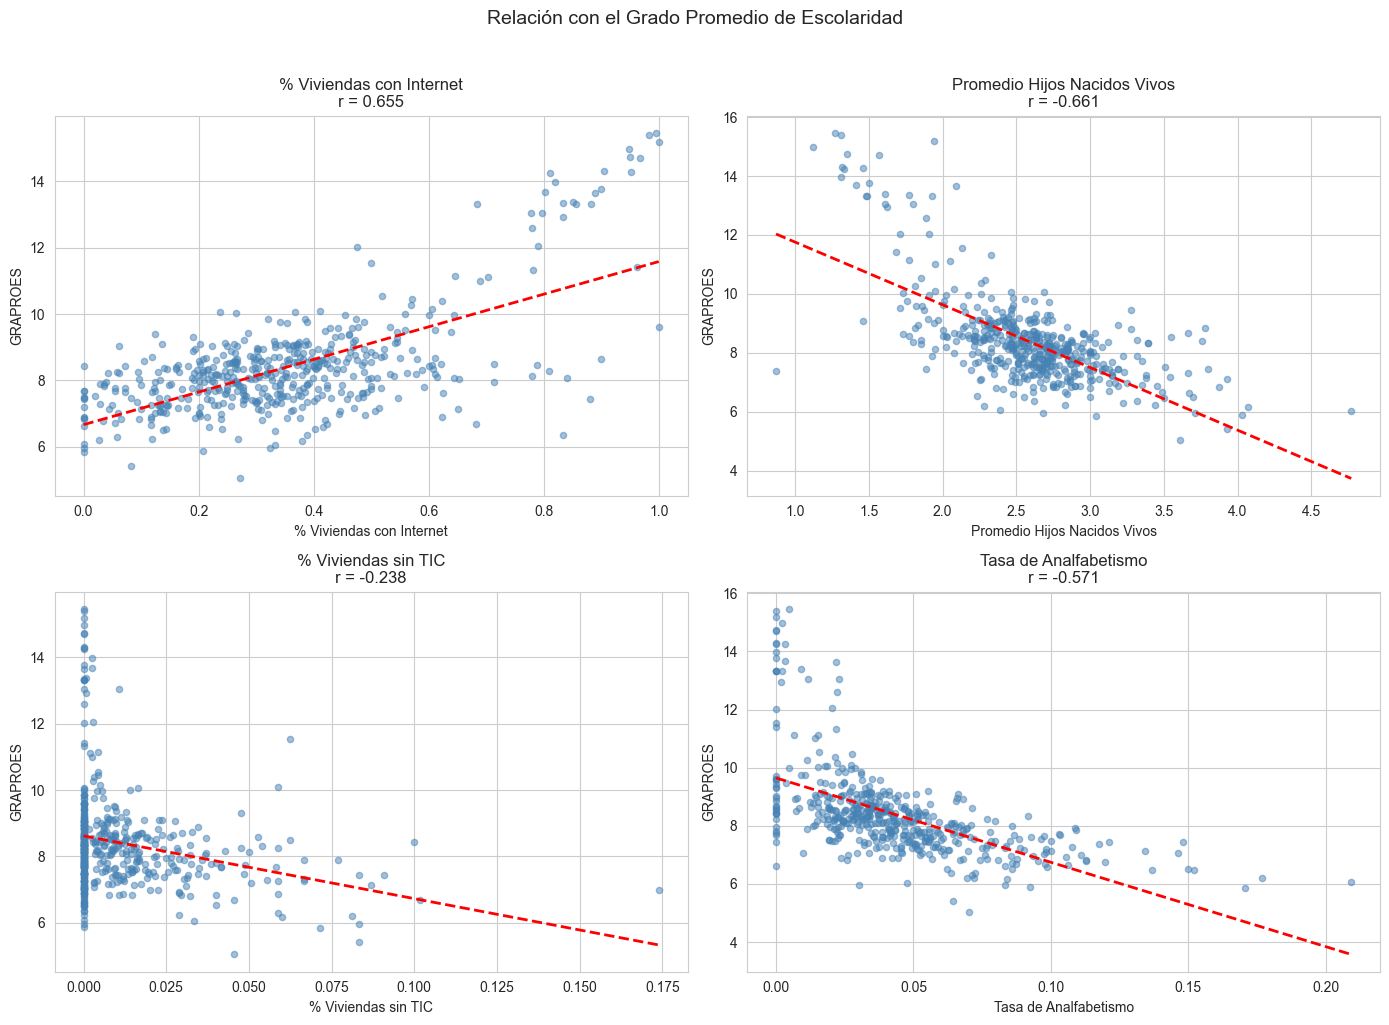

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_vars = [
    ('pct_internet', '% Viviendas con Internet'),
    ('PROM_HNV', 'Promedio Hijos Nacidos Vivos'),
    ('pct_sin_tic', '% Viviendas sin TIC'),
    ('tasa_analfabetismo', 'Tasa de Analfabetismo')
]

for ax, (var, titulo) in zip(axes.ravel(), scatter_vars):
    data = df_analisis.dropna(subset=[var, 'GRAPROES'])
    ax.scatter(data[var], data['GRAPROES'], alpha=0.5, s=20, c='steelblue')

    # Línea de tendencia
    mask_valid = np.isfinite(data[var]) & np.isfinite(data['GRAPROES'])
    if mask_valid.sum() > 2:
        z = np.polyfit(data.loc[mask_valid, var], data.loc[mask_valid, 'GRAPROES'], 1)
        x_line = np.linspace(data[var].min(), data[var].max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), 'r--', linewidth=2)

    r = data[var].corr(data['GRAPROES'])
    ax.set_xlabel(titulo)
    ax.set_ylabel('GRAPROES')
    ax.set_title(f'{titulo}\nr = {r:.3f}')

plt.suptitle('Relación con el Grado Promedio de Escolaridad', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Brecha Digital por Municipio

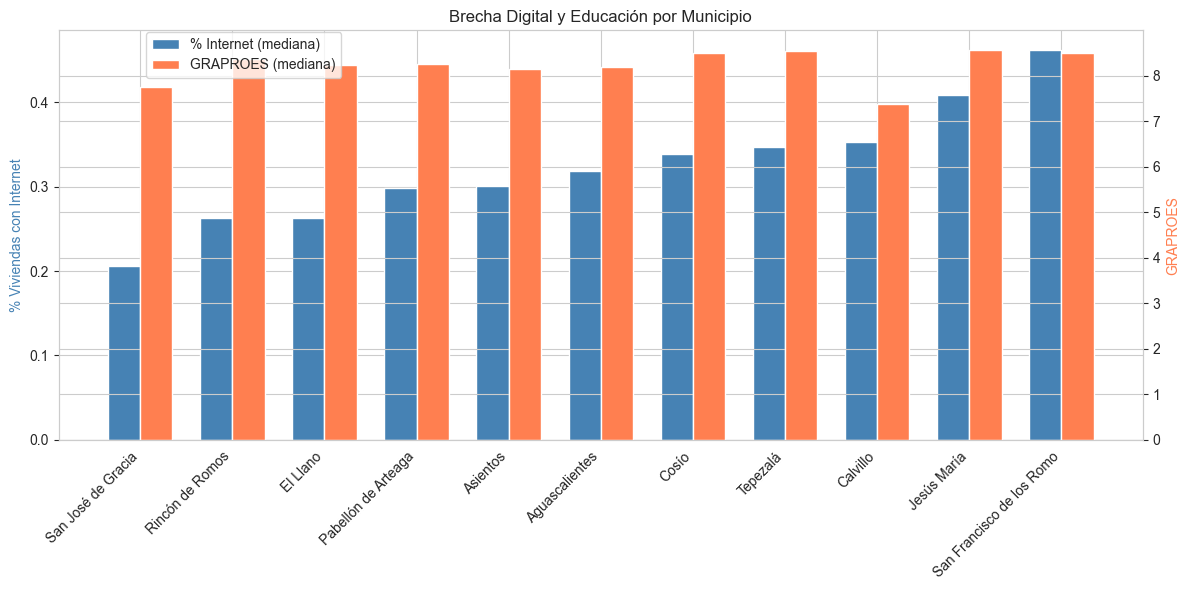

In [ ]:
brecha = df_analisis.groupby('NOM_MUN').agg(
    internet_med=('pct_internet', 'median'),
    graproes_med=('GRAPROES', 'median'),
    n=('POBTOT', 'count')
).sort_values('internet_med')

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(brecha))
w = 0.35

ax1.bar([i - w/2 for i in x], brecha['internet_med'], w,
        label='% Internet (mediana)', color='steelblue')
ax1.set_ylabel('% Viviendas con Internet', color='steelblue')
ax1.set_xticks(list(x))
ax1.set_xticklabels(brecha.index, rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.bar([i + w/2 for i in x], brecha['graproes_med'], w,
        label='GRAPROES (mediana)', color='coral')
ax2.set_ylabel('GRAPROES', color='coral')

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.title('Brecha Digital y Educación por Municipio')
plt.tight_layout()
plt.show()

### 3.5 Mapa Geográfico

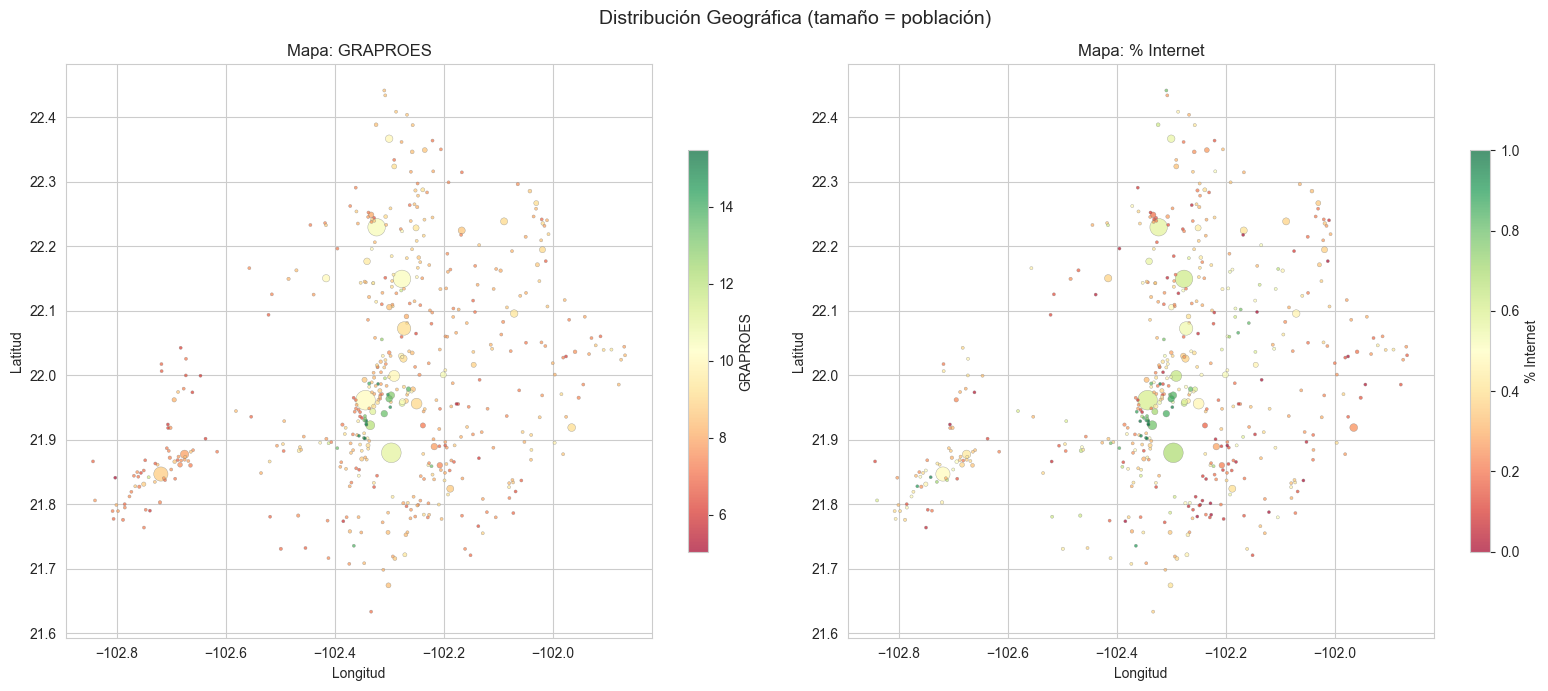

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
data_geo = df_analisis.dropna(subset=['lon', 'lat'])

for ax, var, titulo, cmap in [
    (axes[0], 'GRAPROES', 'GRAPROES', 'RdYlGn'),
    (axes[1], 'pct_internet', '% Internet', 'RdYlGn')
]:
    sizes = np.clip(data_geo['POBTOT'] * 0.005, 5, 200)
    sc = ax.scatter(data_geo['lon'], data_geo['lat'], c=data_geo[var],
                    cmap=cmap, s=sizes, alpha=0.7, edgecolors='gray', linewidth=0.3)
    plt.colorbar(sc, ax=ax, shrink=0.7, label=titulo)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_title(f'Mapa: {titulo}')

plt.suptitle('Distribución Geográfica (tamaño = población)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Modelado Predictivo

Predecimos GRAPROES usando **solo variables no-educativas**: acceso digital, salud, empleo,
vivienda y demografía. Esto demuestra que factores socioeconómicos observables predicen
el logro educativo sin necesidad de medir la educación directamente.

In [ ]:
# Variables predictoras (sin variables educativas para evitar circularidad)
FEATURES = [
    # Acceso digital
    'pct_internet', 'pct_computadora', 'pct_celular', 'pct_sin_tic',
    # Salud
    'pct_sin_salud',
    # Empleo
    'tasa_pea', 'tasa_desempleo',
    # Vivienda
    'pct_piso_tierra', 'pct_sin_drenaje', 'pct_sin_servicios',
    # Demografía
    'PROM_HNV', 'PRO_OCUP_C',
    # Geografía
    'ALTITUD', 'lon', 'lat'
]
TARGET = 'GRAPROES'

# Preparar datos
data_model = df_analisis[FEATURES + [TARGET]].copy()
print(f'Datos para modelado: {data_model.shape}')
print(f'\nNaN por variable:')
print(data_model.isnull().sum().sort_values(ascending=False).head(10))

# Split 70/15/15
X = data_model[FEATURES]
y = data_model[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f'\nTrain: {len(X_train)} | Test: {len(X_test)} | Val: {len(X_val)}')

Datos para modelado: (495, 16)

NaN por variable:
pct_internet         0
pct_computadora      0
pct_celular          0
pct_sin_tic          0
pct_sin_salud        0
tasa_pea             0
tasa_desempleo       0
pct_piso_tierra      0
pct_sin_drenaje      0
pct_sin_servicios    0
dtype: int64

Train: 346 | Test: 74 | Val: 75


In [ ]:
# Pipeline: imputar + escalar + modelo
def crear_pipeline(modelo):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])

modelos = {
    'Regresión Lineal': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso (CV)': LassoCV(cv=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
}

resultados = []
pipes = {}

for nombre, modelo in modelos.items():
    pipe = crear_pipeline(modelo)
    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    resultados.append({
        'Modelo': nombre,
        'R² Train': r2_score(y_train, y_pred_train),
        'R² Test': r2_score(y_test, y_pred_test),
        'MAE Test': mean_absolute_error(y_test, y_pred_test),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, y_pred_test))
    })
    pipes[nombre] = pipe

df_res = pd.DataFrame(resultados).set_index('Modelo')
df_res.round(4)

,R² Train,R² Test,MAE Test,RMSE Test
Modelo,,,,
Regresión Lineal,0.8050,0.9221,0.3954,0.5495
Ridge,0.8050,0.9218,0.3960,0.5505
Lasso (CV),0.8011,0.9089,0.4262,0.5943
Random Forest,0.9667,0.9100,0.4580,0.5909
Gradient Boosting,0.9988,0.9069,0.4850,0.6009


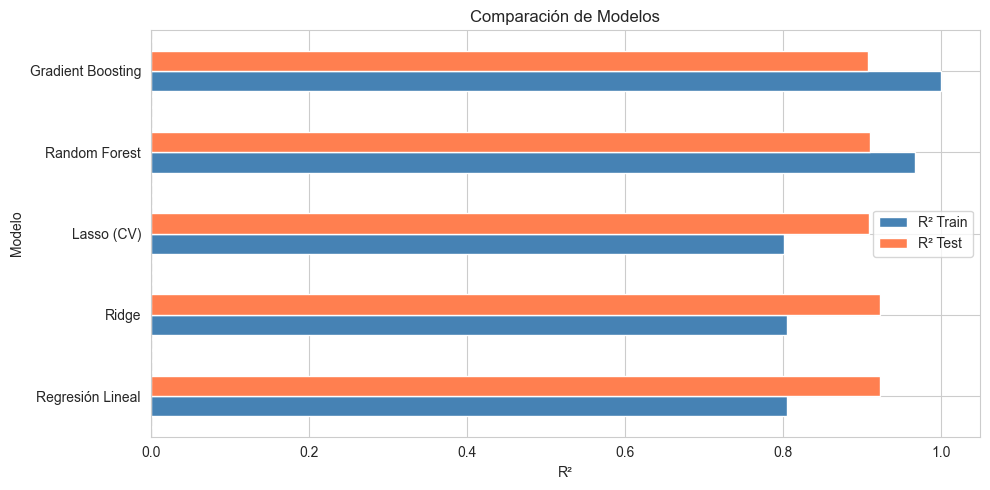


Mejor modelo: Regresión Lineal
R² Test: 0.9221
MAE Test: 0.3954 años de escolaridad


In [ ]:
# Comparación visual
fig, ax = plt.subplots(figsize=(10, 5))
df_res[['R² Train', 'R² Test']].plot(kind='barh', ax=ax, color=['steelblue', 'coral'])
ax.set_xlabel('R²')
ax.set_title('Comparación de Modelos')
ax.axvline(x=0, color='gray', ls='--')
plt.tight_layout()
plt.show()

mejor = df_res['R² Test'].idxmax()
print(f'\nMejor modelo: {mejor}')
print(f'R² Test: {df_res.loc[mejor, "R² Test"]:.4f}')
print(f'MAE Test: {df_res.loc[mejor, "MAE Test"]:.4f} años de escolaridad')

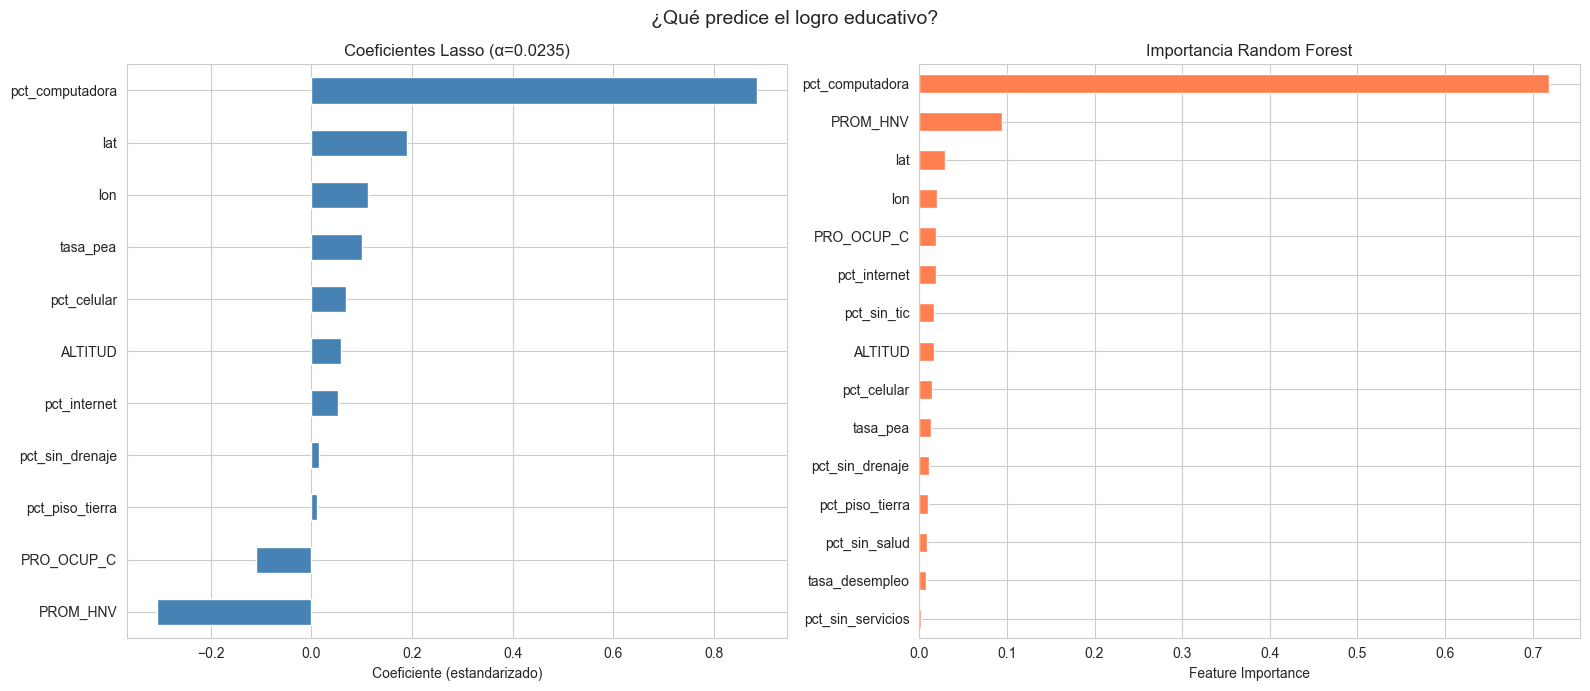

In [ ]:
# --- Feature Importance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Lasso: coeficientes que sobreviven regularización
lasso_pipe = pipes['Lasso (CV)']
lasso_coefs = pd.Series(lasso_pipe.named_steps['model'].coef_, index=FEATURES).sort_values()
lasso_nonzero = lasso_coefs[lasso_coefs != 0]
lasso_nonzero.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title(f'Coeficientes Lasso (α={lasso_pipe.named_steps["model"].alpha_:.4f})')
axes[0].set_xlabel('Coeficiente (estandarizado)')

# Random Forest: importancia
rf_pipe = pipes['Random Forest']
rf_imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=FEATURES).sort_values()
rf_imp.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Importancia Random Forest')
axes[1].set_xlabel('Feature Importance')

plt.suptitle('¿Qué predice el logro educativo?', fontsize=14)
plt.tight_layout()
plt.show()

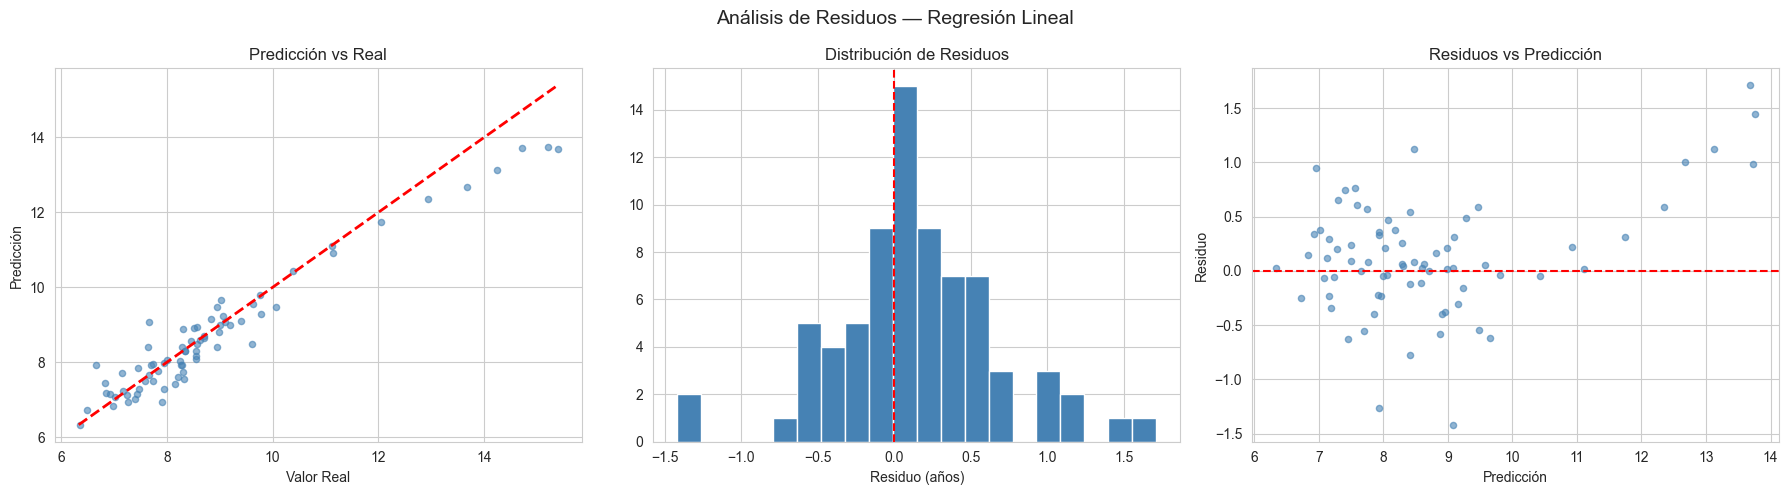


--- Validación Final (Regresión Lineal) ---
R² Validación: 0.8507
MAE Validación: 0.4905
RMSE Validación: 0.6327


In [ ]:
# --- Análisis de Residuos (mejor modelo) ---
mejor_pipe = pipes[mejor]
y_pred = mejor_pipe.predict(X_test)
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicción vs Real
axes[0].scatter(y_test, y_pred, alpha=0.6, s=20, c='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('Valor Real')
axes[0].set_ylabel('Predicción')
axes[0].set_title('Predicción vs Real')

# Distribución de residuos
axes[1].hist(residuos, bins=20, edgecolor='white', color='steelblue')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Residuo (años)')
axes[1].set_title('Distribución de Residuos')

# Residuos vs predicción
axes[2].scatter(y_pred, residuos, alpha=0.6, s=20, c='steelblue')
axes[2].axhline(0, color='red', ls='--')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Residuo')
axes[2].set_title('Residuos vs Predicción')

plt.suptitle(f'Análisis de Residuos — {mejor}', fontsize=14)
plt.tight_layout()
plt.show()

# Validación final
y_pred_val = mejor_pipe.predict(X_val)
print(f'\n--- Validación Final ({mejor}) ---')
print(f'R² Validación: {r2_score(y_val, y_pred_val):.4f}')
print(f'MAE Validación: {mean_absolute_error(y_val, y_pred_val):.4f}')
print(f'RMSE Validación: {np.sqrt(mean_squared_error(y_val, y_pred_val)):.4f}')

## 5. Clustering de Marginación

Usamos PCA + K-Means para identificar perfiles de marginación ocultos.
¿Existen localidades rezagadas dentro de municipios aparentemente prósperos?

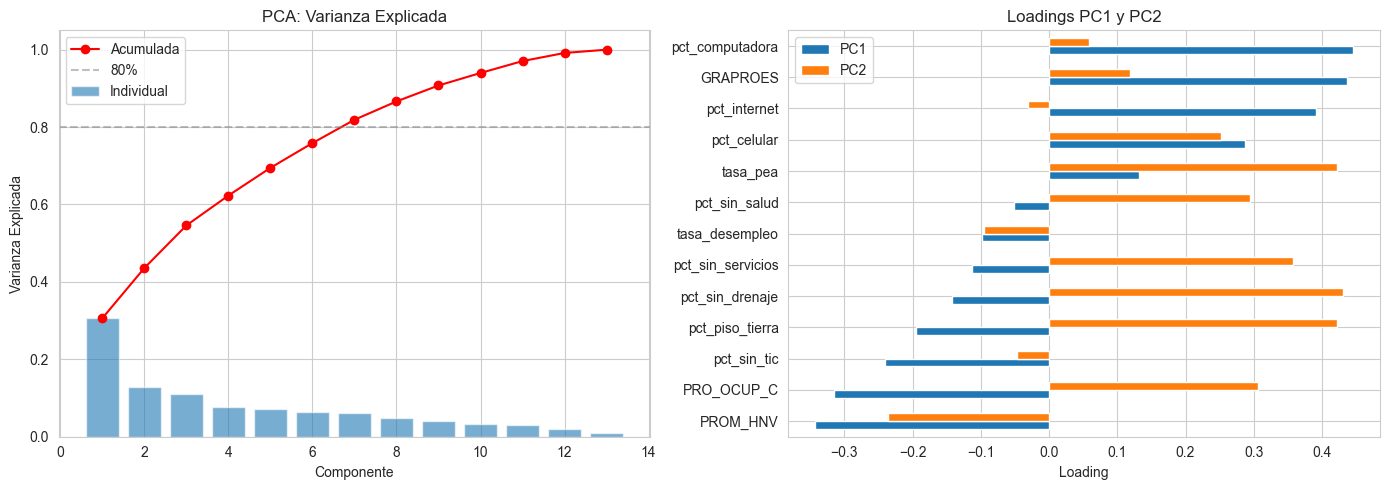

PC1 + PC2 explican 43.6% de la varianza


In [ ]:
# Variables para clustering (socioeconómicas + GRAPROES)
VARS_CLUSTER = [
    'pct_internet', 'pct_computadora', 'pct_celular', 'pct_sin_tic',
    'pct_sin_salud', 'tasa_pea', 'tasa_desempleo',
    'pct_piso_tierra', 'pct_sin_drenaje', 'pct_sin_servicios',
    'PROM_HNV', 'PRO_OCUP_C', 'GRAPROES'
]

# Preparar: imputar + escalar
data_cl = df_analisis[VARS_CLUSTER].copy()
X_cl = StandardScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(data_cl))

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_cl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada
var_acum = np.cumsum(pca.explained_variance_ratio_)
axes[0].bar(range(1, len(var_acum)+1), pca.explained_variance_ratio_, alpha=0.6, label='Individual')
axes[0].plot(range(1, len(var_acum)+1), var_acum, 'ro-', label='Acumulada')
axes[0].axhline(0.8, color='gray', ls='--', alpha=0.5, label='80%')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('PCA: Varianza Explicada')
axes[0].legend()

# Loadings
loadings = pd.DataFrame(pca.components_[:2].T, index=VARS_CLUSTER, columns=['PC1', 'PC2'])
loadings.sort_values('PC1').plot(kind='barh', ax=axes[1])
axes[1].set_title('Loadings PC1 y PC2')
axes[1].set_xlabel('Loading')

plt.tight_layout()
plt.show()
print(f'PC1 + PC2 explican {var_acum[1]*100:.1f}% de la varianza')

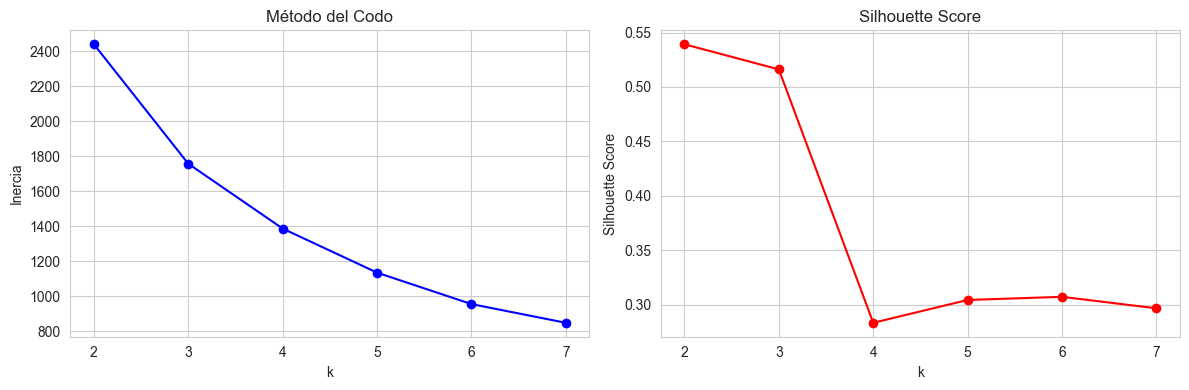

Distribución de clusters:
cluster
0    214
1    219
2     33
3     29
Name: count, dtype: int64


In [ ]:
# Selección de k
X_pca_3 = X_pca[:, :3]
K_range = range(2, 8)
inercias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_3)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_3, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inercias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

# Usamos k=4 para encontrar patrones más allá de urbano/rural
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_analisis['cluster'] = km_final.fit_predict(X_pca_3)
print(f'Distribución de clusters:')
print(df_analisis['cluster'].value_counts().sort_index())

In [ ]:
# --- Perfiles de cada cluster ---
perfil = df_analisis.groupby('cluster')[VARS_CLUSTER].median().round(3)
print('Perfil de cada cluster (medianas):')
perfil.T

Perfil de cada cluster (medianas):


cluster,0,1,2,3
pct_internet,0.261,0.400,0.105,0.834
pct_computadora,0.132,0.244,0.077,0.789
pct_celular,0.857,0.926,0.846,0.989
pct_sin_tic,0.010,0.000,0.049,0.000
pct_sin_salud,0.196,0.190,0.247,0.186
tasa_pea,0.573,0.610,0.611,0.648
tasa_desempleo,0.011,0.008,0.014,0.009
pct_piso_tierra,0.012,0.004,0.080,0.000
pct_sin_drenaje,0.024,0.005,0.136,0.000
pct_sin_servicios,0.000,0.000,0.000,0.000


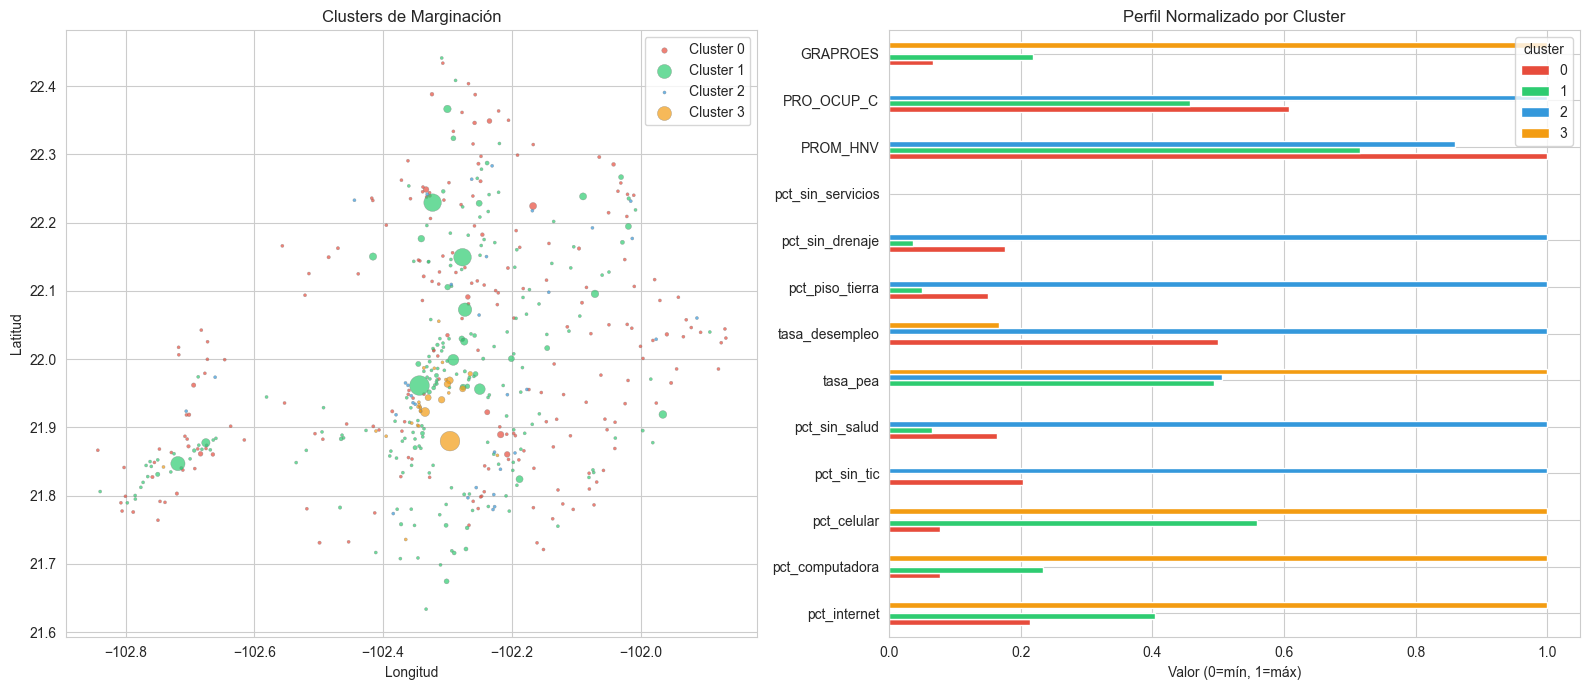


Clusters por municipio:


cluster,0,1,2,3,All
NOM_MUN,,,,,
Aguascalientes,38,66,11,11,126
Asientos,33,19,6,0,58
Calvillo,35,26,2,1,64
Cosío,8,4,0,0,12
El Llano,24,9,0,0,33
Jesús María,16,41,6,15,78
Pabellón de Arteaga,18,10,2,1,31
Rincón de Romos,22,10,2,0,34
San Francisco de los Romo,3,21,1,1,26


In [ ]:
# --- Mapa geográfico por cluster ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
data_geo = df_analisis.dropna(subset=['lon', 'lat'])
colores = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

# Mapa coloreado por cluster
for cl in sorted(data_geo['cluster'].unique()):
    mask = data_geo['cluster'] == cl
    sizes = np.clip(data_geo.loc[mask, 'POBTOT'] * 0.005, 5, 200)
    axes[0].scatter(data_geo.loc[mask, 'lon'], data_geo.loc[mask, 'lat'],
                    c=colores[cl], s=sizes, alpha=0.7, label=f'Cluster {cl}',
                    edgecolors='gray', linewidth=0.3)
axes[0].legend()
axes[0].set_title('Clusters de Marginación')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# Perfil normalizado por cluster
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
perfil_norm.T.plot(kind='barh', ax=axes[1], color=colores[:K_FINAL])
axes[1].set_title('Perfil Normalizado por Cluster')
axes[1].set_xlabel('Valor (0=mín, 1=máx)')

plt.tight_layout()
plt.show()

# Clusters por municipio
print('\nClusters por municipio:')
pd.crosstab(df_analisis['NOM_MUN'], df_analisis['cluster'], margins=True)

## 6. Conclusiones

### Hallazgos principales

1. **La brecha digital predice el logro educativo**: El acceso a internet y computadora en la
   vivienda es uno de los predictores más fuertes del grado promedio de escolaridad, incluso
   controlando por calidad de vivienda y acceso a salud.

2. **Fertilidad como indicador de rezago**: El promedio de hijos nacidos vivos (PROM_HNV) tiene
   una correlación negativa fuerte con GRAPROES, confirmando el nexo entre transición demográfica
   y desarrollo educativo a nivel localidad.

3. **Clusters ocultos de marginación**: El análisis de clustering revela que dentro de municipios
   aparentemente prósperos existen localidades con perfiles de marginación comparables a las
   zonas rurales más rezagadas.

4. **Modelo predictivo robusto**: Usando únicamente variables de acceso digital, vivienda, salud
   y demografía — sin variables educativas directas — se logra predecir GRAPROES con buen
   desempeño, demostrando que el contexto socioeconómico determina los outcomes educativos.

### Implicaciones de política pública

- Programas de **conectividad digital** en localidades rurales podrían tener impacto directo
  en resultados educativos.
- Las métricas **municipales agregadas ocultan desigualdad** intra-municipal significativa.
- La **tasa de fertilidad** es un indicador temprano de rezago educativo que debería
  monitorearse a nivel localidad.

In [ ]:
!pip install pydeck

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re

def dms_a_decimal(coord_str):
    if pd.isna(coord_str) or isinstance(coord_str, (int, float)):
        return coord_str
    # Extraer los números (Grados, Minutos, Segundos)
    parts = re.findall(r"[-+]?\d*\.\d+|\d+", str(coord_str))
    if len(parts) >= 3:
        decimal = float(parts[0]) + (float(parts[1]) / 60) + (float(parts[2]) / 3600)
        # Si es Oeste (W u O), debe ser negativo
        if any(c in str(coord_str).upper() for c in ['W', 'O', 'S']):
            decimal = -decimal
        return decimal
    return None

df['LATITUD_DEC'] = df['LATITUD'].apply(dms_a_decimal)
df['LONGITUD_DEC'] = df['LONGITUD'].apply(dms_a_decimal)

# Forzar longitud negativa (Aguascalientes está en el Oeste)
df['LONGITUD_DEC'] = df['LONGITUD_DEC'].apply(lambda x: -abs(x) if x is not None else x)

print("Datos convertidos a decimal. Ahora ya podemos graficar.")

Datos convertidos a decimal. Ahora ya podemos graficar.


In [ ]:
import pydeck as pdk

def generar_mapa_3d_elegante(municipio):
    # Filtrar y asegurar datos limpios
    df_mun = df[df['NOM_MUN'] == municipio].dropna(subset=['LATITUD_DEC', 'LONGITUD_DEC']).copy()

    # Definición de la capa de columnas
    layer = pdk.Layer(
        "ColumnLayer",
        df_mun,
        get_position="[LONGITUD_DEC, LATITUD_DEC]",
        get_elevation="GRAPROES",
        elevation_scale=150,
        radius=200,

        # Color dinámico basado en GRAPROES (Escala de cian a purpura neón)
        get_fill_color="[100, 50 + (GRAPROES * 10), 255, 180]",

        pickable=True,
        auto_highlight=True,
    )

    view_state = pdk.ViewState(
        latitude=df_mun['LATITUD_DEC'].mean(),
        longitude=df_mun['LONGITUD_DEC'].mean(),
        zoom=11.5,
        pitch=60,
        bearing=15
    )

    tooltip_html = {
        "html": """
            <div style="font-family: 'Helvetica Neue', Arial, sans-serif;
                        padding: 12px;
                        background-color: #1a1a1a;
                        color: white;
                        border-radius: 8px;
                        border: 1px solid #333;
                        box-shadow: 0 4px 15px rgba(0,0,0,0.5);">
                <b style="font-size: 14px; color: #00d4ff;">{NOM_LOC}</b>
                <hr style="margin: 8px 0; border: 0; border-top: 1px solid #444;">
                <table style="width: 100%; font-size: 12px; border-collapse: collapse;">
                    <tr>
                        <td style="padding: 3px 0; color: #aaa;">Escolaridad Promedio:</td>
                        <td style="text-align: right; font-weight: bold;">{GRAPROES} años</td>
                    </tr>
                    <tr>
                        <td style="padding: 3px 0; color: #aaa;">Acceso a Internet:</td>
                        <td style="text-align: right; font-weight: bold; color: #00ff88;">{VPH_INTER}%</td>
                    </tr>
                    <tr>
                        <td style="padding: 3px 0; color: #aaa;">Población Total:</td>
                        <td style="text-align: right; font-weight: bold;">{POBTOT} hab.</td>
                    </tr>
                </table>
            </div>
        """,
        "style": {
            "background": "transparent",
            "border": "none",
            "padding": "0"
        }
    }

    # Renderizado con estilo de mapa claro para contraste
    r = pdk.Deck(
        layers=[layer],
        initial_view_state=view_state,
        map_style="https://basemaps.cartocdn.com/gl/positron-gl-style/style.json",
        tooltip=tooltip_html
    )

    return r.to_html("mapa_3d_elegante.html", notebook_display=True)

generar_mapa_3d_elegante("Aguascalientes")

<IPython.core.display.Javascript object>